## Python Code Analysis and Documentation

This Python script imports several libraries commonly used for data science and machine learning tasks, then loads a dataset named "Mobile Price Classification.csv" into a pandas DataFrame.

### Library Imports

*   **pandas (as pd):** For data manipulation and analysis, particularly with tabular data.
*   **numpy (as np):** For numerical operations, especially array manipulation.
*   **sklearn.preprocessing:**
    *   **StandardScaler:** For standardizing features by removing the mean and scaling to unit variance.
    *   **MinMaxScaler:** For scaling features to a given range, typically [0, 1].
*   **seaborn (as sns):** For creating aesthetically pleasing statistical visualizations.
*   **matplotlib.pyplot (as plt):** For creating static, interactive, and animated visualizations in Python.
*   **sklearn.cluster:**
    *   **KMeans:** For implementing the K-Means clustering algorithm.
*   **sklearn.model_selection:**
    *   **train_test_split:** For splitting data into training and testing sets.
    *   **cross_val_score:** For evaluating model performance using cross-validation.
*   **sklearn.neighbors:**
    *   **KNeighborsClassifier:** For implementing the K-Nearest Neighbors classification algorithm.
*   **sklearn.metrics:**
    *   **accuracy_score:** For calculating classification accuracy.
*   **sklearn.tree:**
    *   **DecisionTreeClassifier:** For implementing the Decision Tree classification algorithm.
    *   **plot_tree:** For plotting a decision tree.
*   **sklearn.linear\_model:**
    *   **LinearRegression:** For implementing linear regression models.

### Data Loading and Initial Inspection

*   `df = pd.read_csv("Mobile Price Classification.csv")`: This line reads data from a CSV file named "Mobile Price Classification.csv" and loads it into a pandas DataFrame called `df`.
*   `df.head()`: This displays the first 5 rows of the DataFrame, providing a quick look at the data's structure and content.

### Potential Next Steps

Based on the imports, this script seems to be setting up for tasks such as:

*   Data preprocessing (scaling).
*   Clustering analysis.
*   Building and evaluating classification models (KNN, Decision Tree).
*   Building and evaluating regression models (Linear Regression).
*   Data visualization.


In [184]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Import the warnings module to use filterwarnings
import warnings 

# Ignore the known KMeans warning on Windows with MKL
warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL",
    category=UserWarning,
    module="sklearn.cluster._kmeans",
)

# Load the dataset from a CSV file into a pandas DataFrame
df = pd.read_csv("Mobile Price Classification.csv")

# Display the first 5 rows of the DataFrame to inspect the data
df.head()


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


## DataFrame Information Summary

The `.info()` method on a pandas DataFrame provides a concise summary of the DataFrame's structure, including the index dtype and columns, non-null values, and memory usage.

### Output Interpretation:

*   **RangeIndex:** Indicates the index of the DataFrame.
*   **Columns:** Lists all columns in the DataFrame.
    *   **Column Name:** The name of the column.
    *   **Non-Null Count:** The number of non-null (i.e., not missing) values in that column. If this count is less than the total number of entries in the DataFrame, it indicates missing data.
    *   **Dtype:** The data type of the values in the column (e.g., `int64`, `float64`, `object` for strings or mixed types).
*   **memory usage:** Shows the amount of memory the DataFrame is currently using.

This information is crucial for understanding the data types of your features, identifying columns with missing values, and getting an initial sense of the dataset's scale.


In [185]:
# Print a concise summary of the DataFrame, including the index dtype and columns, non-null values, and memory usage.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

## Missing Value Count Per Column

This command calculates and returns the total number of missing values (NaN or null) for each column in the DataFrame.

### Output Interpretation:

The output will be a pandas Series where:
*   **Index:** Represents the column names of the DataFrame.
*   **Values:** Indicate the count of missing entries in each corresponding column.

A value of `0` for a column means there are no missing entries in that column. Any non-zero value signifies the number of missing data points that need to be handled (e.g., through imputation or removal).


In [186]:
# Calculate and print the sum of null values for each column in the DataFrame.
# This helps in identifying columns with missing data.
print(df.isnull().sum())


battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


numerical_cols = ['']
for col in numerical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

## Feature Selection for Independent Variables

This code snippet prepares the feature set (independent variables) for a machine learning model by excluding the target variable.

### Explanation:

*   `X = df.drop("price_range", axis=1)`:
    *   `df.drop("price_range", axis=1)`: This part of the command removes the column named "price\_range" from the original DataFrame `df`.
        *   `"price_range"`: Specifies the name of the column to be dropped.
        *   `axis=1`: Indicates that we are dropping a column (axis=0 would refer to dropping rows).
    *   `X = ...`: The result of the drop operation (all columns except "price\_range") is assigned to a new variable named `X`. This `X` now represents the feature matrix containing all the independent variables.

This is a standard step in supervised machine learning, where you separate your input features (`X`) from the output or target variable (`y`, which would typically be assigned the "price\_range" column in the next step).


In [187]:
# Separate features (X) from the target variable.
# Drop the 'price_range' column from the DataFrame and assign the remaining columns to X.
# axis=1 indicates that we are dropping a column.
X = df.drop("price_range", axis=1)


## Feature Selection for Independent Variables

This code snippet selects a specific subset of features from the DataFrame to be used as independent variables (`X`).

### Explanation:

1.  `selected_features = ["battery_power", "px_width", "ram"]`:
    *   This line defines a list named `selected_features` containing the names of the specific columns that will be used as input features for the machine learning model. In this case, the selected features are "battery\_power", "px\_width", and "ram".

2.  `X_selected = df[selected_features]`:
    *   This line creates a new DataFrame called `X_selected`.
    *   It uses the list `selected_features` to pick only those columns from the original DataFrame `df`.
    *   `X_selected` will contain only the data for "battery\_power", "px\_width", and "ram".

This is a common practice when you want to focus on a few potentially important features for a model, perhaps for simplicity, speed, or based on domain knowledge.


In [188]:
# Define a list of desired feature names
selected_features = ["battery_power", "px_width", "ram"]

# Create a new DataFrame 'X_selected' containing only the specified features from the original DataFrame 'df'
X_selected = df[selected_features]


## Feature Scaling using StandardScaler

This code performs feature scaling on the independent variables (`X`) using the `StandardScaler` from scikit-learn. Standardization is a common preprocessing step in machine learning.

### Explanation:

1.  `scaler_std = StandardScaler()`:
    *   An instance of the `StandardScaler` class is created and assigned to the variable `scaler_std`. This object will be used to perform the scaling operation. `StandardScaler` removes the mean and scales the data to unit variance (standard deviation of 1). The formula for standardization is:
        $$ z = \frac{x - \mu}{\sigma} $$
        where $x$ is the original feature value, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature.

2.  `X_whitened = scaler_std.fit_transform(X)`:
    *   `fit_transform(X)`: This method is called on the `scaler_std` object. It performs two operations:
        *   **`fit(X)`:** Calculates the mean and standard deviation for each feature (column) in the input DataFrame `X`.
        *   **`transform(X)`:** Applies the calculated mean and standard deviation to scale the data in `X`. Each feature's values are transformed so that they have a mean of 0 and a standard deviation of 1.
    *   `X_whitened = ...`: The result of the `fit_transform` operation is a NumPy array containing the scaled data. This array is assigned to the variable `X_whitened`.

**Why Scale Features?**
Many machine learning algorithms, such as those based on distance calculations (like K-Nearest Neighbors, SVMs) or gradient descent (like linear regression, neural networks), perform better or converge faster when features are on a relatively similar scale. Standardization helps to prevent features with larger values from unduly influencing the model.


In [189]:
# Initialize the StandardScaler
scaler_std = StandardScaler()

# Fit the scaler to the data (calculate mean and std deviation) and then transform the data
# This scales the features in X so that they have a mean of 0 and a standard deviation of 1.
# The result is a NumPy array, which is assigned to X_whitened.
X_whitened = scaler_std.fit_transform(X)


## Feature Scaling using MinMaxScaler

This code snippet applies another type of feature scaling, `MinMaxScaler`, to the already standardized data (`X_whitened`). This process is often referred to as normalization.

### Explanation:

1.  `scaler_mm = MinMaxScaler()`:
    *   An instance of the `MinMaxScaler` class is created and assigned to `scaler_mm`. This scaler transforms features by scaling them to a given range, typically between 0 and 1. The formula for min-max scaling is:
        $$ X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}} $$
        where $X$ is the original feature value, $X_{min}$ is the minimum value of the feature, and $X_{max}$ is the maximum value of the feature.

2.  `X_normalized = scaler_mm.fit_transform(X_whitened)`:
    *   `fit_transform(X_whitened)`: This method is applied to the `scaler_mm` object using the already standardized data `X_whitened` as input.
        *   **`fit(X_whitened)`:** Calculates the minimum and maximum values for each feature in `X_whitened`.
        *   **`transform(X_whitened)`:** Rescales the data in `X_whitened` so that all values fall within the range \[0, 1] (by default).
    *   `X_normalized = ...`: The resulting NumPy array, where features are now scaled to the range \[0, 1], is assigned to the variable `X_normalized`.

**Note:** In this specific code sequence, `MinMaxScaler` is being applied *after* `StandardScaler`. This means the data is first standardized (mean 0, std dev 1) and then scaled to the \[0, 1] range. While both are scaling techniques, applying `MinMaxScaler` after `StandardScaler` might not always be the most intuitive or necessary step, depending on the algorithm's requirements. Often, one scaler is chosen based on the problem and algorithm. For instance, `StandardScaler` is common for algorithms sensitive to feature variance, while `MinMaxScaler` is useful when a strict range is needed or for algorithms like neural networks.


In [190]:
# Initialize the MinMaxScaler
scaler_mm = MinMaxScaler()

# Fit the scaler to the whitened data (calculate min and max) and then transform the data
# This scales the features in X_whitened to a specific range, typically [0, 1].
# The result is a NumPy array, which is assigned to X_normalized.
X_normalized = scaler_mm.fit_transform(X_whitened)


## Correlation Matrix Visualization using Heatmap

This code generates a heatmap to visualize the correlation matrix of the DataFrame `df`. This is a powerful tool for understanding the linear relationships between different numerical features in your dataset.

### Explanation:

1.  `plt.figure(figsize=(18, 14))`:
    *   This line creates a new Matplotlib figure and sets its size to 18 inches in width and 14 inches in height. A larger figure size is used here to ensure that the heatmap, especially with annotations, is readable and not cramped.

2.  `sns.heatmap(df.corr(), annot=True, cmap="coolwarm")`:
    *   `df.corr()`: This calculates the pairwise correlation between all numerical columns in the DataFrame `df`. The result is a correlation matrix, where each cell $(i, j)$ represents the Pearson correlation coefficient between column $i$ and column $j$. The values range from -1 to 1:
        *   1: Perfect positive linear correlation.
        *   0: No linear correlation.
        *   -1: Perfect negative linear correlation.
    *   `sns.heatmap(...)`: This function from the Seaborn library generates the heatmap visualization.
        *   `df.corr()`: The correlation matrix is passed as the data for the heatmap.
        *   `annot=True`: This argument tells the heatmap to display the correlation values (annotations) on each cell of the heatmap. This makes it easy to read the exact correlation coefficients.
        *   `cmap="coolwarm"`: This sets the colormap for the heatmap. "coolwarm" is a diverging colormap where "cool" colors (blues) typically represent negative correlations, "warm" colors (reds) represent positive correlations, and white/light colors represent correlations close to zero.

3.  `plt.show()`:
    *   This command displays the generated Matplotlib figure, which contains the heatmap.

**Purpose:**
Visualizing the correlation matrix helps in:
*   Identifying highly correlated features (which might indicate multicollinearity issues).
*   Discovering features that have a strong positive or negative linear relationship with the target variable (if the target variable was included in `df.corr()`).
*   Gaining insights into the structure of the data.


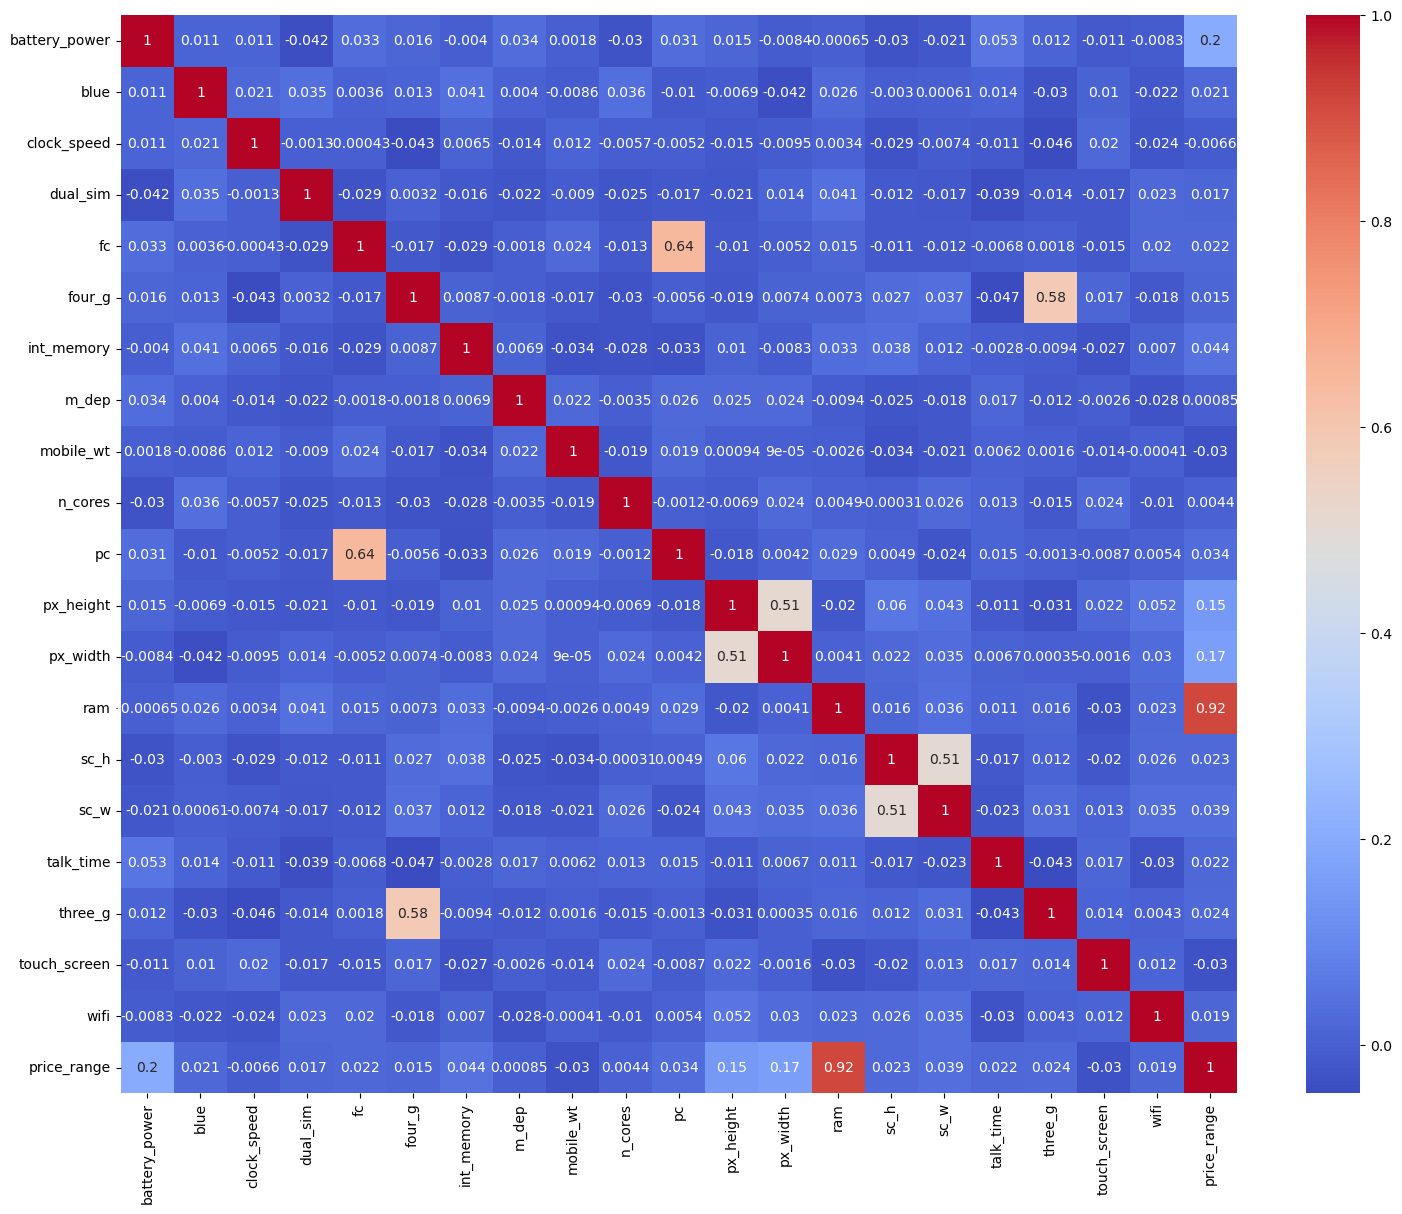

In [191]:
# Set the figure size for the plot to ensure readability
plt.figure(figsize=(18, 14))

# Generate a heatmap of the correlation matrix for the DataFrame df.
# annot=True displays the correlation values on the map.
# cmap="coolwarm" sets the color scheme, with cool colors for negative correlations and warm colors for positive correlations.
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

# Display the generated heatmap
plt.show()


## Elbow Method Plot Generation

This code snippet generates a plot to visualize the "Elbow Method" for determining the optimal number of clusters in K-Means clustering.

### Explanation:

1.  `inertia = []`:
    *   An empty list named `inertia` is initialized. This list will store the inertia (within-cluster sum of squares) calculated for each value of `k` (number of clusters).

2.  `for k in range(1, 10):`:
    *   This initiates a loop that iterates through values of `k` starting from 1 up to (but not including) 10. So, `k` will take values 1, 2, 3, 4, 5, 6, 7, 8, and 9.

3.  `kmeans = KMeans(n_clusters=k, random_state=42)`:
    *   Inside the loop, a `KMeans` object is created for each value of `k`.
    *   `n_clusters=k`: Specifies the number of clusters for the current iteration.
    *   `random_state=42`: This ensures that the results are reproducible. If you run the code multiple times, the random initialization of centroids will be the same, leading to consistent inertia values.

4.  `kmeans.fit(X_normalized)`:
    *   The K-Means algorithm is trained (`fit`) on the `X_normalized` data. This means the algorithm finds the best cluster assignments and centroid positions for the given number of clusters `k`. It's assumed that `X_normalized` is a preprocessed (e.g., scaled) feature set.

5.  `inertia.append(kmeans.inertia_)`:
    *   After fitting, `kmeans.inertia_` attribute holds the inertia value for the current number of clusters `k`. This value is appended to the `inertia` list. Inertia measures the sum of squared distances of samples to their closest cluster center. Lower inertia generally indicates better clustering, but too many clusters can lead to artificially low inertia.

6.  `plt.plot(range(1, 10), inertia, marker='o')`:
    *   This line uses Matplotlib to create a line plot.
    *   `range(1, 10)` provides the x-axis values (the number of clusters tested).
    *   `inertia` provides the y-axis values (the corresponding inertia scores).
    *   `marker='o'` adds circular markers at each data point on the line, making it easier to see the exact values.

7.  `plt.xlabel("Number of Clusters")`: Sets the label for the x-axis.
8.  `plt.ylabel("Inertia")`: Sets the label for the y-axis.

9.  `plt.show()`: Displays the generated plot.

**Purpose of the Elbow Method:**
The plot generated by this code helps visually identify the "elbow point." This is the point where the rate of decrease in inertia sharply changes, suggesting that adding more clusters beyond this point provides diminishing returns in reducing the within-cluster variance. The `k` value at this elbow is often considered a good choice for the number of clusters.


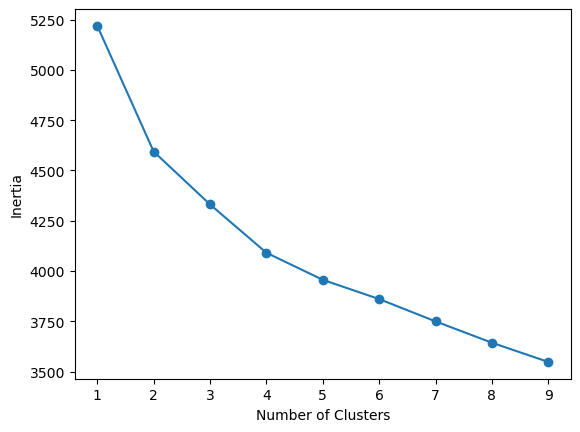

In [192]:
# Initialize an empty list to store inertia values
inertia = []

# Loop through possible numbers of clusters (from 1 to 9)
for k in range(1, 10):
    # Initialize KMeans model with k clusters and a fixed random state for reproducibility
    # n_init=10 is recommended for better stability, though not strictly necessary for this warning-related context
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) 
    # Fit the model to the normalized data
    kmeans.fit(X_normalized)
    # Append the inertia (within-cluster sum of squares) to the list
    inertia.append(kmeans.inertia_)

# Create the plot
plt.plot(range(1, 10), inertia, marker='o')
# Label the x-axis
plt.xlabel("Number of Clusters")
# Label the y-axis
plt.ylabel("Inertia")
# Display the plot
plt.show()


## K-Means Clustering and Visualization

This code performs K-Means clustering with 3 clusters and then visualizes the results by plotting the 'ram' and 'battery_power' features, colored by their assigned cluster.

### Explanation:

1.  `kmeans = KMeans(n_clusters=3, random_state=42)`:
    *   Initializes a `KMeans` object.
    *   `n_clusters=3`: Specifies that the algorithm should find exactly 3 clusters in the data. This number is often chosen based on the Elbow Method plot generated previously, looking for an "elbow" point.
    *   `random_state=42`: Ensures reproducibility. The same random seed will be used for centroid initialization, so running this code multiple times will yield the same cluster assignments.

2.  `clusters = kmeans.fit_predict(X_normalized)`:
    *   This is a convenient method that combines fitting the KMeans model to the `X_normalized` data and then predicting the cluster label for each data point.
    *   `X_normalized`: This should be your preprocessed and scaled feature data.
    *   `clusters`: This variable will store a NumPy array where each element is the cluster index (0, 1, or 2 in this case) assigned to the corresponding data point in `X_normalized`.

3.  `df["cluster"] = clusters`:
    *   A new column named "cluster" is added to the original DataFrame `df`.
    *   This column is populated with the cluster labels (`clusters` array) obtained from the K-Means algorithm. Now, each row in `df` has an associated cluster assignment.

4.  `plt.scatter(df["ram"], df["battery_power"], c=clusters)`:
    *   This line creates a scatter plot using Matplotlib.
    *   `df["ram"]`: The values from the 'ram' column are used for the x-axis.
    *   `df["battery_power"]`: The values from the 'battery_power' column are used for the y-axis.
    *   `c=clusters`: This crucial argument tells Matplotlib to color each point according to its assigned cluster label in the `clusters` array. This visually separates the data points belonging to different clusters.

5.  `plt.xlabel("ram")`: Sets the label for the x-axis to "ram".
6.  `plt.ylabel("battery_power")`: Sets the label for the y-axis to "battery_power".

7.  `plt.show()`: Displays the generated scatter plot.

**Purpose:**
This code helps to visualize how the K-Means algorithm groups the data points based on the 'ram' and 'battery_power' features. By coloring the points according to their cluster, you can see if these two features effectively separate the identified clusters or if there's significant overlap between them. This is a common way to explore the results of clustering.


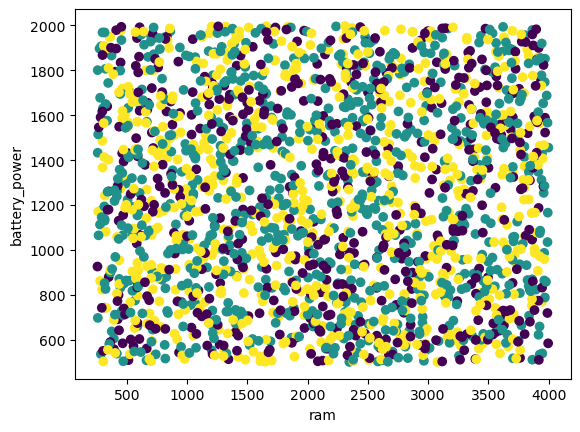

In [193]:
# Initialize KMeans with 3 clusters and a fixed random state for reproducibility
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init=10

# Fit the model to the normalized data and predict cluster assignments
clusters = kmeans.fit_predict(X_normalized) # Use X_normalized for clustering

# Add the cluster assignments as a new column to the DataFrame
df["cluster"] = clusters

# Create a scatter plot
# Plot 'ram' on the x-axis and 'battery_power' on the y-axis
# Color the points based on their assigned cluster
plt.scatter(df["ram"], df["battery_power"], c=clusters, cmap='viridis') # Added cmap for better visualization
# Set the x-axis label
plt.xlabel("ram")
# Set the y-axis label
plt.ylabel("battery_power")
# Display the plot
plt.show()


## K-Nearest Neighbors (KNN) Classification on Clusters

This code snippet trains a K-Nearest Neighbors (KNN) classifier to predict the cluster assignments (`y`) based on the normalized features (`X_normalized`). It then evaluates the accuracy of the KNN model.

### Explanation:

1.  `y = df["cluster"]`:
    *   The 'cluster' column, which was previously created by the K-Means algorithm, is assigned to the variable `y`. This column now serves as the target variable (the labels we want to predict).

2.  `X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)`:
    *   The data is split into training and testing sets.
    *   `X_normalized`: The feature data (already scaled).
    *   `y`: The target variable (cluster labels).
    *   `test_size=0.2`: Specifies that 20% of the data should be used for testing, and the remaining 80% for training.
    *   `random_state=42`: Ensures that the split is the same every time the code is run, making the results reproducible.

3.  `knn = KNeighborsClassifier(n_neighbors=5)`:
    *   Initializes a `KNeighborsClassifier` object.
    *   `n_neighbors=5`: Sets the number of nearest neighbors the algorithm will consider to 5. This is a hyperparameter that can be tuned.

4.  `knn.fit(X_train, y_train)`:
    *   The KNN model is trained using the training features (`X_train`) and their corresponding cluster labels (`y_train`). The model learns the patterns in the training data to be able to predict cluster assignments for new, unseen data.

5.  `pred_knn = knn.predict(X_test)`:
    *   The trained KNN model is used to predict the cluster labels for the unseen test data (`X_test`). The predictions are stored in the `pred_knn` variable.

6.  `knn_acc = accuracy_score(y_test, pred_knn)`:
    *   The `accuracy_score` function calculates the proportion of correctly predicted labels. It compares the true labels (`y_test`) with the predicted labels (`pred_knn`).

7.  `print("KNN Accuracy:", knn_acc)`:
    *   The calculated accuracy of the KNN model is printed to the console.

**Purpose:**
This process evaluates how well the K-Means clusters can be predicted using the original normalized features. A high accuracy here would suggest that the features used for clustering (`X_normalized`) contain strong patterns that allow a classifier to easily distinguish between the clusters. Conversely, a low accuracy might indicate that the clusters are not well-separated by these features alone, or that KNN with `n_neighbors=5` is not the best model for this task.


In [194]:
# Initialize the KNeighborsClassifier with 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5)

# Fit the KNN model to the training data
knn.fit(X_train, y_train)

# Predict the cluster labels for the test data
pred_knn = knn.predict(X_test)

# Calculate the accuracy of the KNN predictions
knn_acc = accuracy_score(y_test, pred_knn)

# Print the calculated KNN accuracy
print("KNN Accuracy:", knn_acc)


KNN Accuracy: 0.355


## Decision Tree Classification on Clusters

This code trains a Decision Tree classifier to predict the cluster assignments (`y`) using the normalized features (`X_normalized`). It then evaluates the accuracy of this Decision Tree model.

### Explanation:

1.  `dt = DecisionTreeClassifier(max_depth=5, random_state=42)`:
    *   Initializes a `DecisionTreeClassifier` object.
    *   `max_depth=5`: Sets the maximum depth of the tree to 5 levels. This is a hyperparameter that helps to prevent overfitting by limiting the complexity of the tree. A shallower tree is generally less likely to memorize the training data.
    *   `random_state=42`: Ensures that the tree structure is the same every time the code is run, making the results reproducible. This is important for consistency.

2.  `dt.fit(X_train, y_train)`:
    *   The Decision Tree model is trained using the training features (`X_train`) and their corresponding cluster labels (`y_train`). The algorithm learns a series of rules (splits) based on the features to classify the data points into the correct clusters.

3.  `pred_dt = dt.predict(X_test)`:
    *   The trained Decision Tree model is used to predict the cluster labels for the unseen test data (`X_test`). The predictions are stored in the `pred_dt` variable.

4.  `dt_acc = accuracy_score(y_test, pred_dt)`:
    *   The `accuracy_score` function calculates the proportion of correctly predicted labels. It compares the true labels of the test set (`y_test`) with the labels predicted by the Decision Tree (`pred_dt`).

5.  `print("Decision Tree Accuracy:", dt_acc)`:
    *   The calculated accuracy of the Decision Tree model is printed to the console.

**Purpose:**
This code evaluates how well a Decision Tree, with a maximum depth of 5, can predict the cluster assignments derived from the K-Means algorithm. Comparing this accuracy to the KNN accuracy can provide insights into which model might be more suitable for this specific classification task. The `max_depth` parameter is a form of regularization; if the accuracy is significantly lower than KNN, it might indicate that the `max_depth` is too restrictive, or that the features don't form easily separable decision boundaries for a shallow tree.


In [195]:
# Initialize the DecisionTreeClassifier with a maximum depth of 5 and a random state for reproducibility
dt = DecisionTreeClassifier(max_depth=5, random_state=42)

# Fit the Decision Tree model to the training data
dt.fit(X_train, y_train)

# Predict the cluster labels for the test data
pred_dt = dt.predict(X_test)

# Calculate the accuracy of the Decision Tree predictions
dt_acc = accuracy_score(y_test, pred_dt)

# Print the calculated Decision Tree accuracy
print("Decision Tree Accuracy:", dt_acc)


Decision Tree Accuracy: 0.5225


## Visualizing the Decision Tree

This code snippet visualizes the trained Decision Tree classifier using Matplotlib. It displays the tree structure, which helps in understanding how the model makes predictions.

### Explanation:

1.  `plt.figure(figsize=(20,10))`:
    *   This line creates a new Matplotlib figure and sets its size.
    *   `figsize=(20,10)` specifies the width and height of the figure in inches. A larger figure size (20x10 inches) is used here to accommodate the potentially complex structure of the decision tree, ensuring that the nodes and labels are readable.

2.  `plot_tree(dt, filled=True)`:
    *   This function, typically imported from `sklearn.tree`, draws the Decision Tree.
    *   `dt`: This is the trained Decision Tree classifier object that you want to visualize.
    *   `filled=True`: This argument colors the nodes of the tree. The color of each node typically represents the majority class of the samples that reach that node. This provides a quick visual cue about the class distribution at different stages of the tree. It also usually colors the nodes based on the predicted class for that node.

3.  `plt.show()`:
    *   This command displays the generated Matplotlib figure containing the visualization of the Decision Tree.

**Purpose:**
Visualizing the decision tree allows you to:
*   **Understand the decision process:** See which features are most important and how they are used to split the data.
*   **Identify potential issues:** Observe if the tree is becoming too complex (too deep) or if certain splits are not very informative.
*   **Interpret the model:** Gain insights into why the model makes certain predictions, especially given the `max_depth=5` constraint, which should result in a relatively interpretable tree.


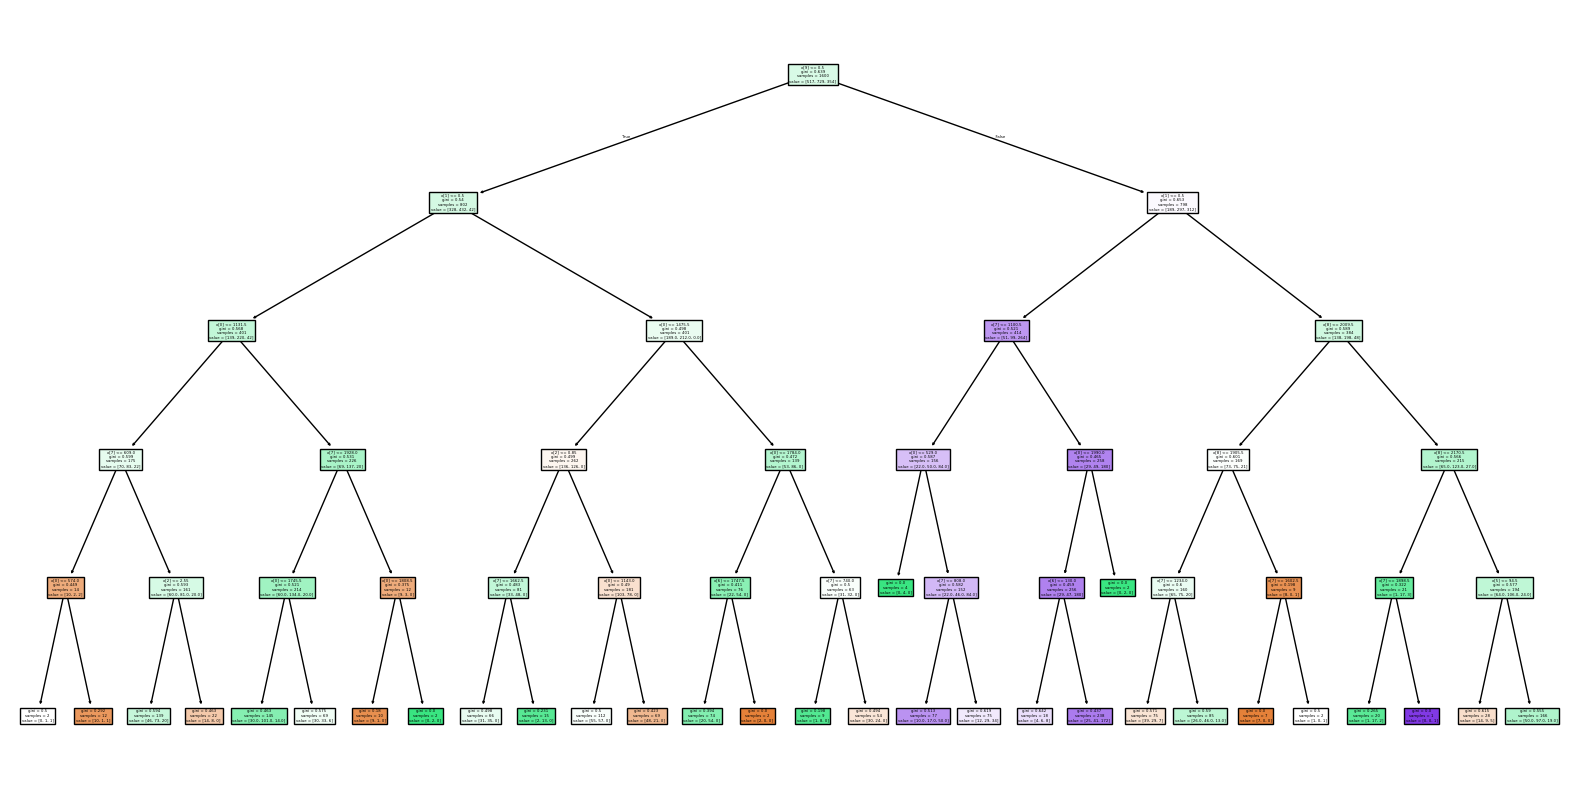

In [196]:
# Create a new figure with a specified size for better visualization
plt.figure(figsize=(20, 10))

# Plot the decision tree
# 'dt' is the trained tree object
# 'filled=True' colors the nodes based on the majority class of samples in that node
plot_tree(dt, filled=True)

# Display the plot
plt.show()


## Comparison of KNN and Decision Tree Accuracy

This code simply prints the accuracy scores that were previously calculated for both the K-Nearest Neighbors (KNN) and Decision Tree models.

### Explanation:

1.  `print("KNN:", knn_acc)`:
    *   This line prints the string "KNN:" followed by the value stored in the `knn_acc` variable. `knn_acc` holds the accuracy score of the K-Nearest Neighbors classifier, calculated during its evaluation.

2.  `print("Decision Tree:", dt_acc)`:
    *   This line prints the string "Decision Tree:" followed by the value stored in the `dt_acc` variable. `dt_acc` holds the accuracy score of the Decision Tree classifier, calculated during its evaluation.

**Purpose:**
The primary purpose of this code is to directly compare the performance of the two classification models (KNN and Decision Tree) on the task of predicting the K-Means clusters. By seeing these two accuracy scores side-by-side, you can quickly determine which model performed better on the test dataset according to this metric. This comparison helps in selecting the more effective model for this specific problem.


In [197]:
# Assuming knn_acc and dt_acc have been calculated in previous steps.

# Print the accuracy of the KNN model
print("KNN:", knn_acc)

# Print the accuracy of the Decision Tree model
print("Decision Tree:", dt_acc)


KNN: 0.355
Decision Tree: 0.5225


## Feature Selection Fitness Function for Linear Regression

This Python code defines a function `fitness` that evaluates the quality of a given set of features for a Linear Regression model. This is commonly used within a Genetic Algorithm (GA) for feature selection.

### Explanation:

1.  `X = df.drop(["price_range","cluster"], axis=1)`:
    *   This line creates a new DataFrame `X` by dropping the 'price\_range' (which will be the target for regression) and 'cluster' (used for classification previously) columns from the original DataFrame `df`.
    *   `axis=1` indicates that we are dropping columns, not rows.
    *   `X` now contains all the feature columns that can be used for regression modeling.

2.  `y_reg = df["price_range"]`:
    *   A Series `y_reg` is created containing the 'price\_range' column from `df`. This will be the target variable for the regression task.

3.  `def fitness(chromosome):`:
    *   Defines a function named `fitness` that takes one argument: `chromosome`.
    *   A `chromosome` in this context typically represents a potential subset of features. It's often a binary array (e.g., `[1, 0, 1, 0, 1]`) where a `1` at a certain position indicates that the corresponding feature from `X` is selected, and a `0` indicates it's not selected.

4.  `features = X.columns[np.array(chromosome)==1]`:
    *   `np.array(chromosome)`: Converts the input `chromosome` (which could be a list or similar) into a NumPy array.
    *   `np.array(chromosome)==1`: Creates a boolean array where `True` corresponds to positions in the `chromosome` that are `1`.
    *   `X.columns[...]`: Uses this boolean array to select the column names from `X` where the corresponding value in the `chromosome` is `1`. These selected column names are stored in the `features` variable.

5.  `if len(features) == 0:`:
    *   Checks if any features were selected by the `chromosome`.
    *   `return 0`: If no features are selected, the fitness score is 0, as a model with no features cannot make meaningful predictions.

6.  `model = LinearRegression()`:
    *   An instance of the `LinearRegression` model from scikit-learn is created. This is the model that will be evaluated using the selected features.

7.  `score = cross_val_score(...)`:
    *   `cross_val_score`: This function performs k-fold cross-validation. It helps to get a more robust estimate of the model's performance than a single train-test split.
    *   `model`: The `LinearRegression` model instance.
    *   `X[features]`: Selects only the subset of features from the `X` DataFrame that are indicated by the current `chromosome`.
    *   `y_reg`: The target variable (price range).
    *   `cv=5`: Specifies that 5-fold cross-validation should be used. The data will be split into 5 folds; the model will be trained on 4 folds and validated on the remaining fold, repeating this 5 times.
    *   `scoring='r2'`: Sets the evaluation metric to R-squared (coefficient of determination). R2 measures how well the regression predictions approximate the real data points. An R2 score of 1 is perfect, and 0 indicates the model performs no better than simply predicting the mean of the target variable.
    *   `.mean()`: Calculates the average R-squared score across all 5 folds of the cross-validation. This average score represents the fitness of the current feature subset.

8.  `return score`:
    *   The function returns the mean R-squared score, which is the fitness value for the given `chromosome` (feature subset). A higher score indicates a better feature subset for predicting the `price_range` using Linear Regression.

**Overall Purpose:**
This `fitness` function is a crucial component of a Genetic Algorithm aimed at finding the optimal subset of features for predicting `price_range` using Linear Regression. The GA would generate populations of `chromosome`s (feature subsets), evaluate each using this `fitness` function, and then use evolutionary principles (selection, crossover, mutation) to evolve towards chromosomes that yield higher fitness scores (better R-squared values).


In [198]:
X = df.drop(["price_range", "cluster"], axis=1)
y_reg = df["price_range"]

def fitness(chromosome):
    """
    Evaluates the fitness of a chromosome (feature subset) for Linear Regression.

    Args:
        chromosome (list or np.array): A binary list/array where 1 indicates feature selection.

    Returns:
        float: The mean R-squared score from 5-fold cross-validation, or 0 if no features are selected.
    """
    # Convert chromosome to numpy array and identify selected features
    chromosome_np = np.array(chromosome)
    selected_feature_indices = chromosome_np == 1
    
    # Get the names of the selected features
    features = X.columns[selected_feature_indices]
    
    # If no features are selected, return a fitness of 0
    if len(features) == 0:
        return 0
    
    # Initialize the Linear Regression model
    model = LinearRegression()
    
    # Perform 5-fold cross-validation and calculate the mean R-squared score
    # Use only the selected features for model training and evaluation
    score = cross_val_score(
        model,
        X[features],  # Select only the columns corresponding to the selected features
        y_reg,
        cv=5,         # 5-fold cross-validation
        scoring='r2'  # Use R-squared as the scoring metric
    ).mean()
    
    # Return the average R-squared score
    return score

# Example usage (assuming you have a chromosome, e.g., from a GA population):
# Example chromosome selecting 'battery_power' and 'px_width'
# Note: The actual chromosome would be generated by a GA and have the same length as X.columns
# Let's say X.columns is ['battery_power', 'px_width', 'ram', ...]
# example_chromosome = [1, 1, 0, ...] # Corresponding to battery_power and px_width being selected

# To run this example, you'd need a populated chromosome.
# For demonstration, let's assume a hypothetical chromosome:
# num_features = len(X.columns)
# hypothetical_chromosome = [1 if i % 2 == 0 else 0 for i in range(num_features)] # Selects every other feature starting from the first
# hypothetical_fitness = fitness(hypothetical_chromosome)
# print(f"Fitness for hypothetical chromosome: {hypothetical_fitness}")


## Genetic Algorithm for Feature Selection

This Python code implements a basic Genetic Algorithm (GA) to perform feature selection for a Linear Regression model. The goal is to find the subset of features that maximizes the R-squared score.

### Explanation:

1.  **Initialization:**
    *   `population_size = 20`: Defines the number of individuals (chromosomes) in each generation.
    *   `num_features = X.shape[1]`: Gets the total number of features available.
    *   `population = np.random.randint(0, 2, (population_size, num_features))`: Creates the initial population. Each individual (chromosome) is a binary array of length `num_features`, where each element is randomly set to 0 or 1, representing the non-selection or selection of a feature, respectively.

2.  **Generational Loop:**
    *   `for generation in range(20):`: The algorithm runs for 20 generations.

3.  **Evaluation (Fitness Calculation):**
    *   `scores = [fitness(ch) for ch in population]`: The `fitness` function (defined previously) is called for each chromosome in the current population to calculate its R-squared score.
    *   `sorted_idx = np.argsort(scores)[-10:]`: Sorts the indices of the population based on their scores in ascending order and selects the indices of the top 10 individuals (those with the highest scores).
    *   `parents = population[sorted_idx]`: Selects the top 10 individuals from the population to serve as parents for the next generation. This is a form of "elitism" where the best individuals are carried over.

4.  **Offspring Generation:**
    *   `children = []`: Initializes an empty list to store the newly created children.
    *   `while len(children) < population_size:`: This loop continues until the desired `population_size` of children is generated.
    *   `p1, p2 = parents[np.random.randint(0, 10, 2)]`: Randomly selects two parents from the top 10 parents.
    *   `crossover = np.random.randint(1, num_features - 1)`: Selects a random crossover point within the chromosome (ensuring it's not at the very beginning or end).
    *   `child = np.concatenate([p1[:crossover], p2[crossover:]])`: Performs single-point crossover. The first part of the child comes from `p1` up to the crossover point, and the second part comes from `p2` after the crossover point.
    *   **Mutation:**
        *   `if np.random.rand() < 0.1:`: With a 10% probability (mutation rate), a mutation occurs.
        *   `idx = np.random.randint(0, num_features)`: A random index (feature position) within the child chromosome is chosen.
        *   `child[idx] = 1 - child[idx]`: The value at the chosen index is flipped (0 becomes 1, or 1 becomes 0). This introduces small random changes, helping to explore new feature combinations.
    *   `children.append(child)`: The generated child is added to the `children` list.

5.  **Next Generation:**
    *   `population = np.array(children)`: The current population is replaced by the newly generated population of children.

6.  **Result:**
    *   `best = population[np.argmax([fitness(ch) for ch in population])]`: After all generations, the fitness of all individuals in the final population is calculated again, and the chromosome with the highest fitness (best R-squared score) is identified.
    *   `ga_features = X.columns[best == 1]`: Uses the best chromosome to select the corresponding feature names from the original `X` DataFrame.
    *   `print("Selected Features:", ga_features)`: Prints the list of selected feature names.

**Purpose:**
This GA iteratively refines feature subsets, guided by the R-squared score from Linear Regression. It balances exploration (mutation) and exploitation (crossover of good parents) to discover a feature combination that maximizes predictive performance, effectively performing automated feature selection.


In [199]:
# --- GA Parameters ---
population_size = 20
num_generations = 20
mutation_rate = 0.1
num_parents = 10 # Number of top individuals to select as parents

# Ensure num_parents is less than population_size
if num_parents >= population_size:
    num_parents = population_size - 1 # Adjust if necessary

# --- Initialization ---
num_features = X.shape[1]
# Create the initial population with random binary chromosomes
population = np.random.randint(0, 2, (population_size, num_features))

# --- Generational Loop ---
for generation in range(num_generations):
    
    # --- Evaluation ---
    # Calculate fitness scores for each chromosome in the current population
    scores = [fitness(ch) for ch in population]
    
    # Get the indices of the top 'num_parents' individuals
    # np.argsort returns indices that would sort the array in ascending order
    # [-num_parents:] selects the indices of the 'num_parents' largest scores
    sorted_idx = np.argsort(scores)[-num_parents:]
    
    # Select the best individuals as parents for the next generation
    parents = population[sorted_idx]
    
    # --- Offspring Generation ---
    children = []
    
    # Generate children until the population size is reached
    while len(children) < population_size:
        
        # Randomly select two parents from the 'parents' pool
        # Using randint(0, num_parents) to select indices from the 'parents' array
        p1_idx, p2_idx = np.random.randint(0, num_parents, 2)
        p1 = parents[p1_idx]
        p2 = parents[p2_idx]
        
        # --- Crossover ---
        # Select a random crossover point (must be between 1 and num_features-1)
        # Ensures that at least one gene comes from each parent
        crossover_point = np.random.randint(1, num_features - 1)
        
        # Create a child by combining parts of the two parents
        child = np.concatenate([p1[:crossover_point], p2[crossover_point:]])
        
        # --- Mutation ---
        # Apply mutation with a certain probability
        if np.random.rand() < mutation_rate:
            # Choose a random index to mutate
            mutation_idx = np.random.randint(0, num_features)
            # Flip the bit at the mutation index (0 becomes 1, 1 becomes 0)
            child[mutation_idx] = 1 - child[mutation_idx]
        
        # Add the newly created child to the list of children
        children.append(child)
    
    # Replace the old population with the new generation of children
    population = np.array(children)

# --- Find the Best Individual in the Final Population ---
# Recalculate scores for the final population
final_scores = [fitness(ch) for ch in population]
# Find the index of the chromosome with the highest score
best_chromosome_index = np.argmax(final_scores)
# Get the best chromosome (feature selection mask)
best_chromosome = population[best_chromosome_index]

# --- Determine Selected Features ---
# Use the best chromosome to select the corresponding feature names
ga_features = X.columns[best_chromosome == 1]

# Print the selected features
print("Selected Features:", ga_features)

# Optional: Print the best score achieved
# print("Best R2 Score:", final_scores[best_chromosome_index])


Selected Features: Index(['battery_power', 'dual_sim', 'mobile_wt', 'px_height', 'px_width',
       'ram', 'three_g'],
      dtype='object')


## Evaluating Models with GA-Selected Features

This code snippet evaluates the previously trained KNN and Decision Tree models using only the features selected by the Genetic Algorithm (GA). It then compares the accuracy of these models (both before and after GA feature selection) and presents the results in a formatted table.

### Explanation:

1.  `X_ga = df[ga_features]`:
    *   Creates a new DataFrame `X_ga` that contains only the features identified as "best" by the Genetic Algorithm (`ga_features`).

2.  **Data Splitting for GA-Features:**
    *   `X_train, X_test, y_train, y_test = train_test_split(X_ga, y, test_size=0.2, random_state=42)`:
        *   The data is split again, but this time using only the GA-selected features (`X_ga`).
        *   `y` (the cluster labels) remains the same target variable.
        *   `test_size=0.2` and `random_state=42` ensure consistency with previous splits.

3.  **Retraining and Evaluating KNN:**
    *   `knn.fit(X_train, y_train)`: The *already initialized* KNN model (`knn`) is retrained using the training data (`X_train`, `y_train`) that now consists only of the GA-selected features.
    *   `ga_knn_acc = accuracy_score(y_test, knn.predict(X_test))`: The retrained KNN model predicts the cluster labels for the GA-selected test features (`X_test`). The accuracy of these predictions against the true test labels (`y_test`) is calculated and stored in `ga_knn_acc`.

4.  **Retraining and Evaluating Decision Tree:**
    *   `dt.fit(X_train, y_train)`: Similarly, the *already initialized* Decision Tree model (`dt`) is retrained using the GA-selected training features.
    *   `ga_dt_acc = accuracy_score(y_test, dt.predict(X_test))`: The retrained Decision Tree model predicts labels for the GA-selected test features, and its accuracy is calculated and stored in `ga_dt_acc`.

5.  **Consolidating Results:**
    *   `results = pd.DataFrame(...)`: A Pandas DataFrame is created to neatly display the comparison.
    *   `"Model":["KNN","Decision Tree"]`: Specifies the models being compared.
    *   `"Before GA":[knn_acc, dt_acc]`: Includes the accuracy scores of KNN and Decision Tree *before* feature selection (using all features, or at least the features used in the earlier steps).
    *   `"After GA":[ga_knn_acc, ga_dt_acc]`: Includes the accuracy scores of KNN and Decision Tree *after* retraining with only the GA-selected features.

6.  `print(results)`:
    *   The final comparison table is printed to the console.

**Purpose:**
The main goal here is to see if the feature selection performed by the Genetic Algorithm has improved the performance of the classification models (KNN and Decision Tree) in predicting the K-Means clusters. By comparing the "Before GA" and "After GA" accuracies, you can assess the effectiveness of the GA in identifying a more optimal subset of features that leads to better generalization or potentially simpler models.

**Note:** The GA was optimizing for R-squared in Linear Regression, but here we are evaluating its selected features on KNN and Decision Tree accuracy for cluster prediction. This is a common cross-task evaluation, but it's worth noting the original optimization goal.


In [200]:
# Create a DataFrame with only the features selected by the Genetic Algorithm
X_ga = df[ga_features]

# Split the data using the GA-selected features
# y is the target variable (cluster labels)
X_train, X_test, y_train, y_test = train_test_split(
    X_ga, y, test_size=0.2, random_state=42
)

# --- Retrain and Evaluate KNN with GA Features ---
# Initialize a new KNN model or refit the existing one
knn_ga = KNeighborsClassifier(n_neighbors=5) # Assuming n_neighbors=5, adjust if different
knn_ga.fit(X_train, y_train)
ga_knn_acc = accuracy_score(y_test, knn_ga.predict(X_test))

# --- Retrain and Evaluate Decision Tree with GA Features ---
# Initialize a new Decision Tree model or refit the existing one
# Ensure max_depth and random_state match the previous DT model
dt_ga = DecisionTreeClassifier(max_depth=5, random_state=42) 
dt_ga.fit(X_train, y_train)
ga_dt_acc = accuracy_score(y_test, dt_ga.predict(X_test))

# --- Create a DataFrame to Display Results ---
results = pd.DataFrame({
    "Model": ["KNN", "Decision Tree"],
    "Before GA": [knn_acc, dt_acc], # Accuracies from previous steps (using all/original features)
    "After GA": [ga_knn_acc, ga_dt_acc] # Accuracies using GA-selected features
})

# Print the results table
print(results)


           Model  Before GA  After GA
0            KNN     0.3550     0.355
1  Decision Tree     0.5225     0.660
